In [3]:
# Install required packages
!pip install pandas numpy scikit-learn matplotlib seaborn nltk

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [10]:
# Import the dataset
df = pd.read_csv("/content/sample_data/train.csv")

# Sanity check to make sure that the data is still there
df.head()
df.columns


Index(['resume_text', 'job_description_text', 'label'], dtype='object')

In [12]:
# Get some basic data information
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel counts:")
print(df['label'].value_counts())

Shape: (6241, 3)

Column names:
Index(['resume_text', 'job_description_text', 'label'], dtype='object')

Missing values:
resume_text             0
job_description_text    0
label                   0
dtype: int64

Label counts:
label
No Fit           3143
Potential Fit    1556
Good Fit         1542
Name: count, dtype: int64


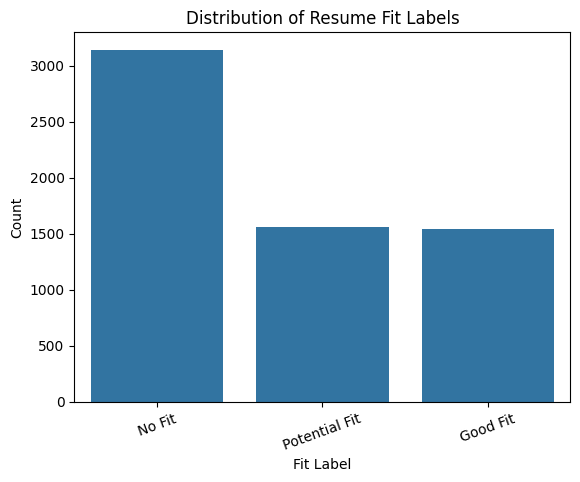

In [13]:
# Visualize the label distr
sns.countplot(data=df, x='label')
plt.title("Distribution of Resume Fit Labels")
plt.xlabel("Fit Label")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [14]:
# Clean the text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['resume_clean'] = df['resume_text'].apply(clean_text)
df['job_clean'] = df['job_description_text'].apply(clean_text)

df[['resume_clean', 'job_clean', 'label']].head()

,resume_clean,job_clean,label
0,summaryhighly motivated sales associate with e...,net2source inc is an award winning total workf...,No Fit
1,professional summarycurrently working with cat...,at salas obrien we tell our clients that were ...,No Fit
2,summaryi started my construction career in jun...,schweitzer engineering laboratories sel infras...,No Fit
3,summarycertified electrical foremanwith thirte...,mizick miller company inc is looking for a dyn...,No Fit
4,summarywith extensive experience in business r...,life at capgemini capgemini supports all aspec...,No Fit


In [15]:
# Combine Resume and Job Description
df['combined_text'] = df['resume_clean'] + " " + df['job_clean']

X = df['combined_text']
y = df['label']

In [16]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
# Now actually build the NLP Model
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=5000, stop_words='english')),
                ('classifier', LogisticRegression(max_iter=1000))])

In [19]:
#Evaluate the model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6365092073658927

Classification Report:
               precision    recall  f1-score   support

     Good Fit       0.64      0.55      0.59       309
       No Fit       0.64      0.81      0.72       629
Potential Fit       0.63      0.36      0.46       311

     accuracy                           0.64      1249
    macro avg       0.63      0.58      0.59      1249
 weighted avg       0.64      0.64      0.62      1249

